In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.amp import GradScaler, autocast
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from transformers import pipeline
from diffusers import StableDiffusionXLPipeline
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "svg"
import kagglehub
import requests
from PIL import Image
from io import BytesIO

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# Task 1 (Text Generation with Transformers)

The model will imitate Shakespeare's style.

https://github.com/karpathy/char-rnn/blob/master/data/tinyshakespeare/input.txt

In [4]:
batch_size = 128
block_size = 128
max_iters = 1500
eval_interval = 300
learning_rate = 5e-4
eval_iters = 200
n_embd = 512
n_head = 8
n_layer = 6
dropout = 0.2
vocab_size = 500

In [5]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text


def get_stats(ids):
    counts = {}
    
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
        
    return counts


def merge(ids, pair, idx):
    newids = []
    i = 0
    
    while i < len(ids):
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
            newids.append(idx)
            i += 2
        else:
            newids.append(ids[i])
            i += 1

    return newids


tokens = list(text.encode("utf-8"))
num_merges = vocab_size - 256
ids = list(tokens)
merges = {}

for i in range(num_merges):
    stats = get_stats(ids)
    if not stats: break
    pair = max(stats, key=stats.get)
    idx = 256 + i
    ids = merge(ids, pair, idx)
    merges[pair] = idx

vocab = {idx: bytes([idx]) for idx in range(256)}
for (p0, p1), idx in merges.items():
    vocab[idx] = vocab[p0] + vocab[p1]


def decode(ids):
    tokens = b"".join(vocab[idx] for idx in ids)
    
    return tokens.decode("utf-8", errors="replace")


def encode(text):
    ids = list(text.encode("utf-8"))
    
    while len(ids) >= 2:
        stats = get_stats(ids)
        pair = min(stats.keys(), key=lambda p: merges.get(p, float("inf")))
        if pair not in merges: break
        ids = merge(ids, pair, merges[pair])

    return ids


data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]


def get_batch(split):
    source = train_data if split == "train" else val_data
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i+block_size] for i in ix])
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])
    
    return x.to(device), y.to(device)

In [6]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    
    def forward(self, x):
        B, T, C = x.shape
        k, q = self.key(x), self.query(x)
        wei = q @ k.transpose(-2, -1) * (C**-0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        
        return wei @ v


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    
    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.sa = MultiHeadAttention(n_head, n_embd // n_head)
        self.ffwd = FeedForward(n_embd)
        self.ln1, self.ln2 = nn.LayerNorm(n_embd), nn.LayerNorm(n_embd)

    
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        
        return x


class GPTModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    
    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = self.blocks(tok_emb + pos_emb)
        logits = self.lm_head(self.ln_f(x))

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            
        return logits, loss

    
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -block_size:])
            probs = F.softmax(logits[:, -1, :], dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
            
        return idx

In [7]:
model = GPTModel(vocab_size).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scaler = GradScaler(device)


@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with autocast(device_type=device, dtype=torch.float16):
                _, loss = model(X, Y)
            losses[k] = loss.item()
            
        out[split] = losses.mean()
    
    model.train()
    
    return out


for i in range(1, max_iters+1):
    if i == 1 or i % eval_interval == 0 or i == max_iters:
        losses = estimate_loss()
        print(f"Step: [{i}/{max_iters}] | Train loss: {losses["train"]:.4f} | Validation loss: {losses["val"]:.4f}")

    xb, yb = get_batch("train")
    
    with autocast(device_type=device, dtype=torch.float16):
        logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

Step: [1/1500] | Train loss: 6.3867 | Validation loss: 6.3801
Step: [300/1500] | Train loss: 2.8982 | Validation loss: 3.3061
Step: [600/1500] | Train loss: 2.3692 | Validation loss: 2.9844
Step: [900/1500] | Train loss: 2.0432 | Validation loss: 2.9908
Step: [1200/1500] | Train loss: 1.7042 | Validation loss: 3.1100
Step: [1500/1500] | Train loss: 1.3510 | Validation loss: 3.3234


In [8]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=500)[0].tolist()))

 in one thing thereof;
Lewis, belike one alone cannot teach one in the night.

PRINCE:
DurY never branch if that need the
noble roaches, where the very given make a rotest berty
of the maids o' my pace or abold crede,--O, let me hear
Keep Tybalt: herefore comes this in the the
mosticular!

PRINCE EDWARD:
You lords, do not but, Juliet-claim Rutland?

BISHABRAd wlord, my fortres.

DERBY:
Then, by my lord, but a voice, you must confess me;
And you shall this be contented.

KING HENRY VI:
You should might wow, my lord, to Buckingham;
And welcome your hands, closely me shall stand up.

HENRY BOLINGBROKE:
'Twield them friend them fair do void me grance.
Fare--if I cannot go be well to Claudio's;
And you have nearned vow'd away awhile;
Having no more remorses in all despected
Atless laber sleepulate or wretched age,
Seek oft Somerset, three-evilent 
In weeds spoil'd, the timerness of all the while
Was children and herself to her;
For then mor


# Task 2 (Neural style transfer)

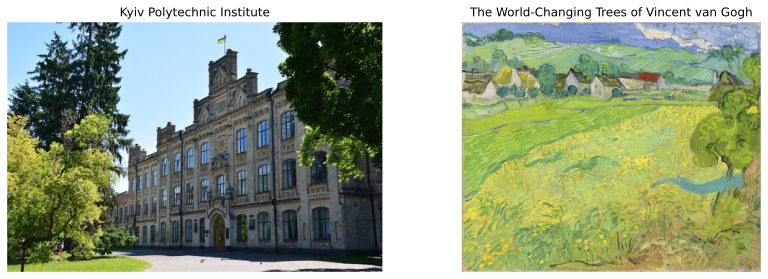

In [9]:
urls = [
    "https://raw.githubusercontent.com/nik4nd/data-mining-labs/main/images/kpi.jpg",
    "https://raw.githubusercontent.com/nik4nd/data-mining-labs/main/images/vincent_van_gogh.jpg"
]

images = []
for url in urls:
    images.append(Image.open(BytesIO(requests.get(url).content)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(images[0])
axes[0].set_title("Kyiv Polytechnic Institute")
axes[0].axis("off")
axes[1].imshow(images[1])
axes[1].set_title("The World-Changing Trees of Vincent van Gogh")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [10]:
def load_image(image, max_size=400, shape=None):
    size = max_size if max(image.size) > max_size else max(image.size)
    if shape:
        size = shape
        
    in_transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])

    image = in_transform(image).unsqueeze(0)
    
    return image.to(device)


def convert(tensor):
    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1, 2, 0)
    image = image * (0.229, 0.224, 0.225) + (0.485, 0.456, 0.406)
    image = image.clip(0, 1)
    
    return image

In [12]:
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features
for param in vgg.parameters():
    param.requires_grad_(False)
vgg.to(device)


def get_features(image, model):
    layers = {
        "0": "conv1_1",
        "5": "conv2_1",
        "10": "conv3_1",
        "19": "conv4_1",
        "21": "conv4_2",
        "28": "conv5_1"
    }
    features = {}
    x = image
    
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    
    return features


def gram_matrix(tensor):
    _, d, h, w = tensor.size()
    tensor = tensor.view(d, h * w)
    gram = torch.mm(tensor, tensor.t())
    
    return gram

Step: [1/400]	| Total Loss: 42627.2539
Step: [50/400]	| Total Loss: 10973.3340
Step: [100/400]	| Total Loss: 6516.4600
Step: [150/400]	| Total Loss: 5023.5938
Step: [200/400]	| Total Loss: 4357.5337
Step: [250/400]	| Total Loss: 3956.0132
Step: [300/400]	| Total Loss: 3666.3413
Step: [350/400]	| Total Loss: 3450.1636
Step: [400/400]	| Total Loss: 3291.6582


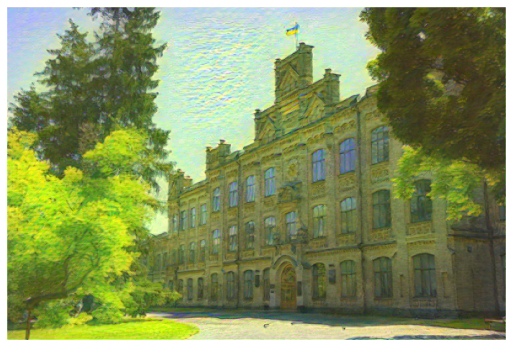

In [14]:
content = load_image(images[0]).to(device)
style = load_image(images[1], shape=content.shape[-2:]).to(device)

target = content.clone().requires_grad_(True).to(device)

style_weights = {"conv1_1": 1.0, "conv2_1": 0.75, "conv3_1": 0.2, "conv4_1": 0.2, "conv5_1": 0.2}
content_weight = 1e4
style_weight = 1e2
tv_weight = 1e-6

content_features = get_features(content, vgg)
style_features = get_features(style, vgg)
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

optimizer = optim.LBFGS([target])
steps = 400
i = [0]

while i[0] <= steps:
    def closure():
        optimizer.zero_grad()
        target_features = get_features(target, vgg)
        
        content_loss = torch.mean((target_features["conv4_2"] - content_features["conv4_2"])**2)
        
        style_loss = 0
        for layer in style_weights:
            target_gram = gram_matrix(target_features[layer])
            style_gram = style_grams[layer]
            layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram)**2)
            _, d, h, w = target_features[layer].shape
            style_loss += layer_style_loss / (d * h * w)
            
        tv_loss = torch.sum(torch.abs(target[:, :, :, :-1] - target[:, :, :, 1:])) + \
                  torch.sum(torch.abs(target[:, :, :-1, :] - target[:, :, 1:, :]))

        total_loss = content_weight * content_loss + style_weight * style_loss + tv_weight * tv_loss
        total_loss.backward()
        
        i[0] += 1
        if i[0] == 1 or i[0] % 50 == 0:
            print(f"Step: [{i[0]}/{steps}]\t| Total Loss: {total_loss.item():.4f}")
            
        return total_loss

    optimizer.step(closure)

final_img = convert(target)
plt.figure(figsize=(10, 6))
plt.imshow(final_img)
plt.axis("off")
plt.show()

# Task 3 (a)

In [15]:
path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")
df = pd.read_csv(f"{path}/bbc-news-data.csv", sep="\t")

df = df.dropna(subset=["content", "category"])

sample_df = df.groupby("category").sample(n=50, random_state=0)
texts = sample_df["content"].tolist()
true_labels = sample_df["category"].tolist()
candidate_labels = df["category"].unique().tolist()

In [16]:
def conduct_model_inference(model, batch_size):
    classifier = pipeline("zero-shot-classification", model=model, device=device)
    results = classifier(texts, candidate_labels, batch_size=batch_size, truncation=True)
    predictions = [res["labels"][0] for res in results]

    return predictions

In [18]:
bart_large_mnli = conduct_model_inference("facebook/bart-large-mnli", 16)

print(f"Accuracy: {accuracy_score(true_labels, bart_large_mnli):.2f}\n")
print(classification_report(true_labels, bart_large_mnli))

Device set to use cuda


Accuracy: 0.62

               precision    recall  f1-score   support

     business       0.44      0.88      0.58        50
entertainment       0.69      0.54      0.61        50
     politics       0.79      0.74      0.76        50
        sport       0.89      0.64      0.74        50
         tech       0.59      0.32      0.42        50

     accuracy                           0.62       250
    macro avg       0.68      0.62      0.62       250
 weighted avg       0.68      0.62      0.62       250



In [20]:
nli_distilroberta_base = conduct_model_inference("cross-encoder/nli-distilroberta-base", 32)

print(f"Accuracy: {accuracy_score(true_labels, nli_distilroberta_base):.2f}\n")
print(classification_report(true_labels, nli_distilroberta_base))

Device set to use cuda


Accuracy: 0.66

               precision    recall  f1-score   support

     business       0.68      0.76      0.72        50
entertainment       0.70      0.84      0.76        50
     politics       0.72      0.26      0.38        50
        sport       0.80      0.88      0.84        50
         tech       0.44      0.54      0.49        50

     accuracy                           0.66       250
    macro avg       0.67      0.66      0.64       250
 weighted avg       0.67      0.66      0.64       250



# Task 3 (c)

In [22]:
model = "stabilityai/stable-diffusion-xl-base-1.0"
pipe = StableDiffusionXLPipeline.from_pretrained(model, torch_dtype=torch.float16, variant="fp16", use_safetensors=True)
pipe.enable_model_cpu_offload()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

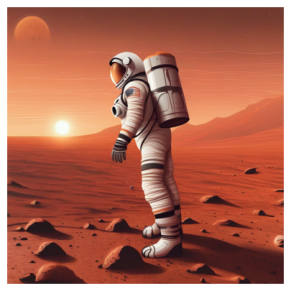

In [23]:
prompt = "Astronaut standing on Mars at sunset"

generator = torch.Generator(device=device).manual_seed(0)

image = pipe(prompt=prompt, generator=generator, num_inference_steps=30, guidance_scale=15).images[0]

plt.figure(figsize=(10, 5))
plt.imshow(image)
plt.axis("off")
plt.show()